## Exploratory Data Assessment

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

_NOTEBOOK_DIR = Path.cwd()
_candidates = [_NOTEBOOK_DIR, *_NOTEBOOK_DIR.parents]
for _base in _candidates:
    if (_base / "data" / "voyages_enriched.parquet").exists():
        PROJECT_DIR = _base
        PARQUET_PATH = _base / "data" / "voyages_enriched.parquet"
        break
    if (_base / "NorthSea_Emissions_Dashboard_GitHub" / "data" / "voyages_enriched.parquet").exists():
        PROJECT_DIR = _base / "NorthSea_Emissions_Dashboard_GitHub"
        PARQUET_PATH = PROJECT_DIR / "data" / "voyages_enriched.parquet"
        break
else:
    PROJECT_DIR = _NOTEBOOK_DIR
    PARQUET_PATH = PROJECT_DIR / "data" / "voyages_enriched.parquet"

OUTPUT_DIR = PROJECT_DIR / "eda_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_START_YEAR = 2018
ANALYSIS_END_YEAR = 2021
MIN_COUNTRY_PAIR_INTENSITY_RECORDS = 30
TOP_N = 20

GREEN = "#1F5A46"
ORANGE = "#D97446"
BLUE = "#56B4E9"
INK = "#1F2B25"

plt.rcdefaults()  # retain Matplotlib's default font family
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlecolor": INK,
    "axes.labelcolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})
sns.set_theme(style="whitegrid", font_scale=0.95)

def save_table(table, filename):
    path = TABLE_DIR / filename
    table.to_csv(path, index=False)
    print(f"Saved: {path}")

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved: {path}")


## 1. Load the validated analytical fields

In [2]:
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {PARQUET_PATH}")

analysis_columns = [
    "unixtimestamp_o", "unixtimestamp_d", "departure_year", "departure_month",
    "country_o", "country_d", "imo", "mmsi", "ship_type_clean", "dwt",
    "delta_dist_km", "delta_time_s", "CO2", "country_pair", "route_directional",
    "CO2_ME_kg", "CO2_AE_kg", "CO2_boiler_kg",
]

df_source = pd.read_parquet(PARQUET_PATH, columns=analysis_columns)
source_row_count = len(df_source)

df_source["departure_time"] = pd.to_datetime(df_source["unixtimestamp_o"], unit="s", errors="coerce")
df_source["arrival_time"] = pd.to_datetime(df_source["unixtimestamp_d"], unit="s", errors="coerce")

for column in ["dwt", "delta_dist_km", "delta_time_s", "CO2", "CO2_ME_kg", "CO2_AE_kg", "CO2_boiler_kg"]:
    df_source[column] = pd.to_numeric(df_source[column], errors="coerce")

in_scope = df_source["departure_year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
outside_scope_count = int((~in_scope).sum())
df = df_source.loc[in_scope].copy()

print(f"Rows in enriched dataset: {source_row_count:,}")
print(f"Rows in the 2018–2021 analytical population: {len(df):,}")
print(f"Rows outside the analytical period: {outside_scope_count:,}")


Rows in enriched dataset: 5,838,724
Rows in the 2018–2021 analytical population: 5,835,843
Rows outside the analytical period: 2,881


## 2. Structural and quality assessment

In [3]:
dataset_overview = pd.DataFrame({
    "metric": [
        "source_rows", "analytical_rows", "records_outside_period", "unique_imo",
        "unique_mmsi", "unique_origin_countries", "unique_destination_countries",
        "unique_country_pairs", "unique_ship_types", "earliest_departure",
        "latest_departure", "latest_arrival", "total_co2_kg", "total_distance_km",
    ],
    "value": [
        source_row_count, len(df), outside_scope_count, df["imo"].nunique(dropna=True),
        df["mmsi"].nunique(dropna=True), df["country_o"].nunique(dropna=True),
        df["country_d"].nunique(dropna=True), df["country_pair"].nunique(dropna=True),
        df["ship_type_clean"].nunique(dropna=True), df["departure_time"].min(),
        df["departure_time"].max(), df["arrival_time"].max(), df["CO2"].sum(),
        df["delta_dist_km"].sum(),
    ],
})

quality_checks = pd.DataFrame({
    "check": [
        "missing_imo", "missing_origin_country", "missing_destination_country",
        "missing_departure_timestamp", "missing_arrival_timestamp", "missing_co2",
        "negative_co2_records", "zero_co2_records", "non_positive_distance_records",
        "missing_dwt_records", "country_pair_mismatches", "component_share_closure_error",
    ],
    "value": [
        df["imo"].isna().sum(), df["country_o"].isna().sum(), df["country_d"].isna().sum(),
        df["departure_time"].isna().sum(), df["arrival_time"].isna().sum(), df["CO2"].isna().sum(),
        (df["CO2"] < 0).sum(), (df["CO2"] == 0).sum(), (df["delta_dist_km"] <= 0).sum(),
        df["dwt"].isna().sum(),
        (df["country_pair"] != np.where(
            df["country_o"].astype(str) <= df["country_d"].astype(str),
            df["country_o"].astype(str) + " ↔ " + df["country_d"].astype(str),
            df["country_d"].astype(str) + " ↔ " + df["country_o"].astype(str),
        )).sum(),
        np.nan,
    ],
})

component_total = df[["CO2_ME_kg", "CO2_AE_kg", "CO2_boiler_kg"]].sum(axis=1, min_count=3)
valid_component_total = component_total > 0
share_sum = (
    df.loc[valid_component_total, "CO2_ME_kg"] / component_total[valid_component_total]
    + df.loc[valid_component_total, "CO2_AE_kg"] / component_total[valid_component_total]
    + df.loc[valid_component_total, "CO2_boiler_kg"] / component_total[valid_component_total]
)
quality_checks.loc[
    quality_checks["check"] == "component_share_closure_error", "value"
] = float((share_sum - 1).abs().max())

missing_values = (
    df[analysis_columns].isna().sum().rename("missing_count").reset_index()
    .rename(columns={"index": "column_name"})
)
missing_values["missing_percentage"] = missing_values["missing_count"] / len(df) * 100
missing_values = missing_values.sort_values("missing_percentage", ascending=False)

numeric_summary = df[["dwt", "delta_dist_km", "delta_time_s", "CO2"]].describe().T.reset_index()

for table, filename in [
    (dataset_overview, "dataset_overview.csv"),
    (quality_checks, "data_quality_checks.csv"),
    (missing_values, "missing_values.csv"),
    (numeric_summary, "numeric_summary.csv"),
]:
    save_table(table, filename)

display(dataset_overview)
display(quality_checks)
display(missing_values.head(12))


Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/dataset_overview.csv
Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/data_quality_checks.csv
Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/missing_values.csv
Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/numeric_summary.csv


,metric,value
0,source_rows,5838724
1,analytical_rows,5835843
2,records_outside_period,2881
3,unique_imo,25834
4,unique_mmsi,26467
5,unique_origin_countries,137
6,unique_destination_countries,143
7,unique_country_pairs,2077
8,unique_ship_types,16
9,earliest_departure,2018-01-01 00:00:20


,check,value
0,missing_imo,0.000000e+00
1,missing_origin_country,0.000000e+00
2,missing_destination_country,0.000000e+00
3,missing_departure_timestamp,0.000000e+00
4,missing_arrival_timestamp,0.000000e+00
5,missing_co2,0.000000e+00
6,negative_co2_records,0.000000e+00
7,zero_co2_records,0.000000e+00
8,non_positive_distance_records,1.710000e+02
9,missing_dwt_records,3.965000e+03


,column_name,missing_count,missing_percentage
9,dwt,3965,0.067942
1,unixtimestamp_d,0,0.000000
16,CO2_AE_kg,0,0.000000
15,CO2_ME_kg,0,0.000000
14,route_directional,0,0.000000
13,country_pair,0,0.000000
12,CO2,0,0.000000
11,delta_time_s,0,0.000000
10,delta_dist_km,0,0.000000
0,unixtimestamp_o,0,0.000000


## 3. Temporal coverage and voyage-distance distribution

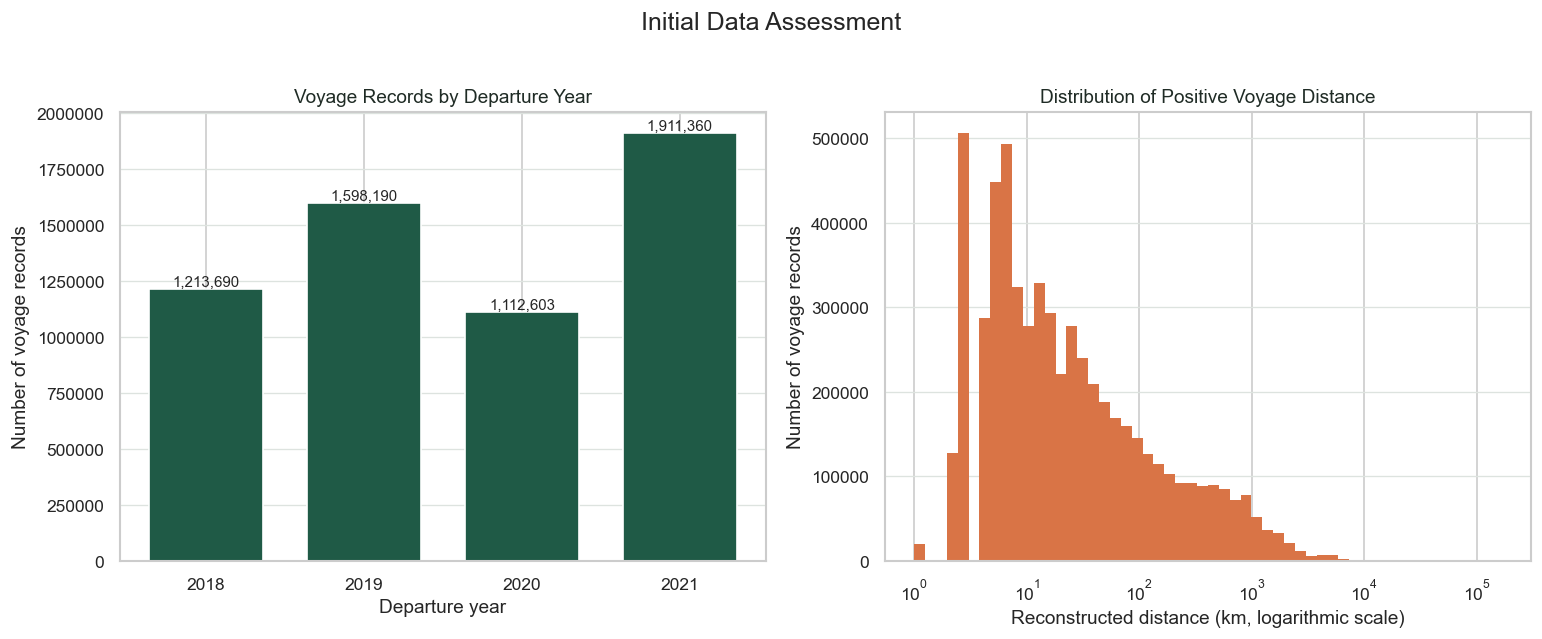

Saved: /Users/vivi/Documents/ERP/eda_outputs/figures/initial_data_assessment.png


In [4]:
annual_counts = df.groupby("departure_year").size().reindex(range(2018, 2022), fill_value=0)
positive_distance = df.loc[df["delta_dist_km"] > 0, "delta_dist_km"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
bars = axes[0].bar(annual_counts.index.astype(str), annual_counts.values, color=GREEN, width=0.72)
axes[0].set_title("Voyage Records by Departure Year")
axes[0].set_xlabel("Departure year", fontsize=12)
axes[0].set_ylabel("Number of voyage records", fontsize=12)
axes[0].ticklabel_format(axis="y", style="plain")
axes[0].grid(axis="y", color="#DDE3DF", linewidth=0.8)
for bar, value in zip(bars, annual_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

distance_bins = np.logspace(np.log10(positive_distance.min()), np.log10(positive_distance.max()), 55)
axes[1].hist(positive_distance, bins=distance_bins, color=ORANGE, edgecolor="none")
axes[1].set_xscale("log")
axes[1].set_title("Distribution of Positive Voyage Distance")
axes[1].set_xlabel("Reconstructed distance (km, logarithmic scale)", fontsize=12)
axes[1].set_ylabel("Number of voyage records", fontsize=12)
axes[1].ticklabel_format(axis="y", style="plain")
axes[1].grid(axis="y", color="#DDE3DF", linewidth=0.8)
fig.suptitle("Initial Data Assessment", fontsize=15, y=1.02)
fig.tight_layout()
save_figure(fig, "initial_data_assessment.png")


## 4. Ship-type structure

Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/ship_type_distribution.csv


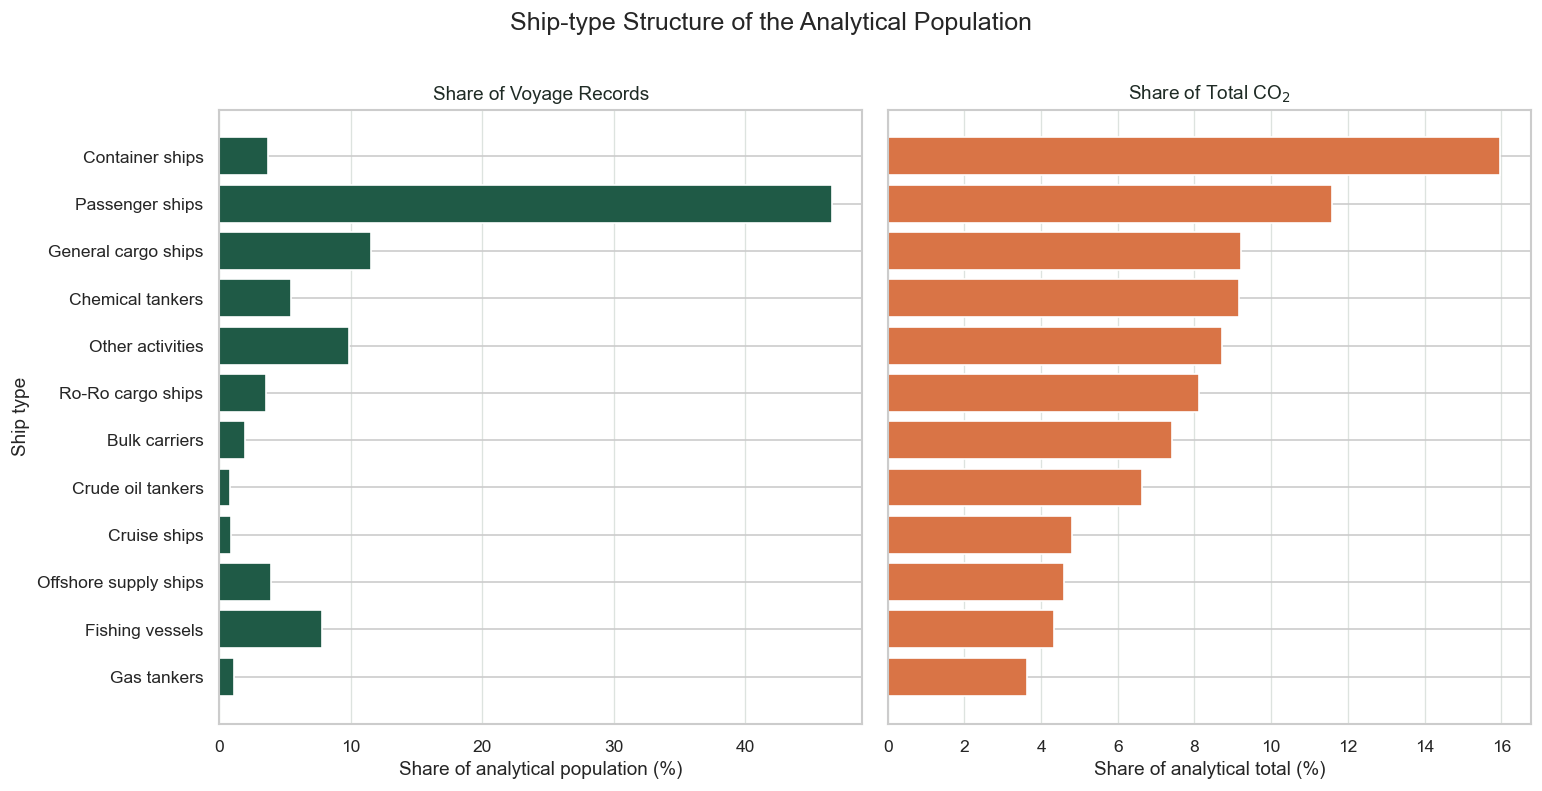

Saved: /Users/vivi/Documents/ERP/eda_outputs/figures/ship_type_structure.png


In [5]:
ship_type_summary = (
    df.groupby("ship_type_clean", dropna=False)
    .agg(record_count=("CO2", "size"), unique_vessels=("imo", "nunique"), total_co2_kg=("CO2", "sum"))
    .reset_index()
)
ship_type_summary["record_share_pct"] = 100 * ship_type_summary["record_count"] / ship_type_summary["record_count"].sum()
ship_type_summary["co2_share_pct"] = 100 * ship_type_summary["total_co2_kg"] / ship_type_summary["total_co2_kg"].sum()
ship_type_summary = ship_type_summary.sort_values("total_co2_kg", ascending=False)
save_table(ship_type_summary, "ship_type_distribution.csv")

top = ship_type_summary.head(12).sort_values("total_co2_kg")
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)
axes[0].barh(top["ship_type_clean"], top["record_share_pct"], color=GREEN)
axes[0].set_title("Share of Voyage Records")
axes[0].set_xlabel("Share of analytical population (%)")
axes[0].set_ylabel("Ship type")
axes[0].grid(axis="x", color="#DDE3DF", linewidth=0.8)

axes[1].barh(top["ship_type_clean"], top["co2_share_pct"], color=ORANGE)
axes[1].set_title(r"Share of Total CO$_2$")
axes[1].set_xlabel("Share of analytical total (%)")
axes[1].grid(axis="x", color="#DDE3DF", linewidth=0.8)
fig.suptitle("Ship-type Structure of the Analytical Population", fontsize=15, y=1.01)
fig.tight_layout()
save_figure(fig, "ship_type_structure.png")


## 5. Origin–destination concentration

Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/origin_destination_co2_matrix.csv


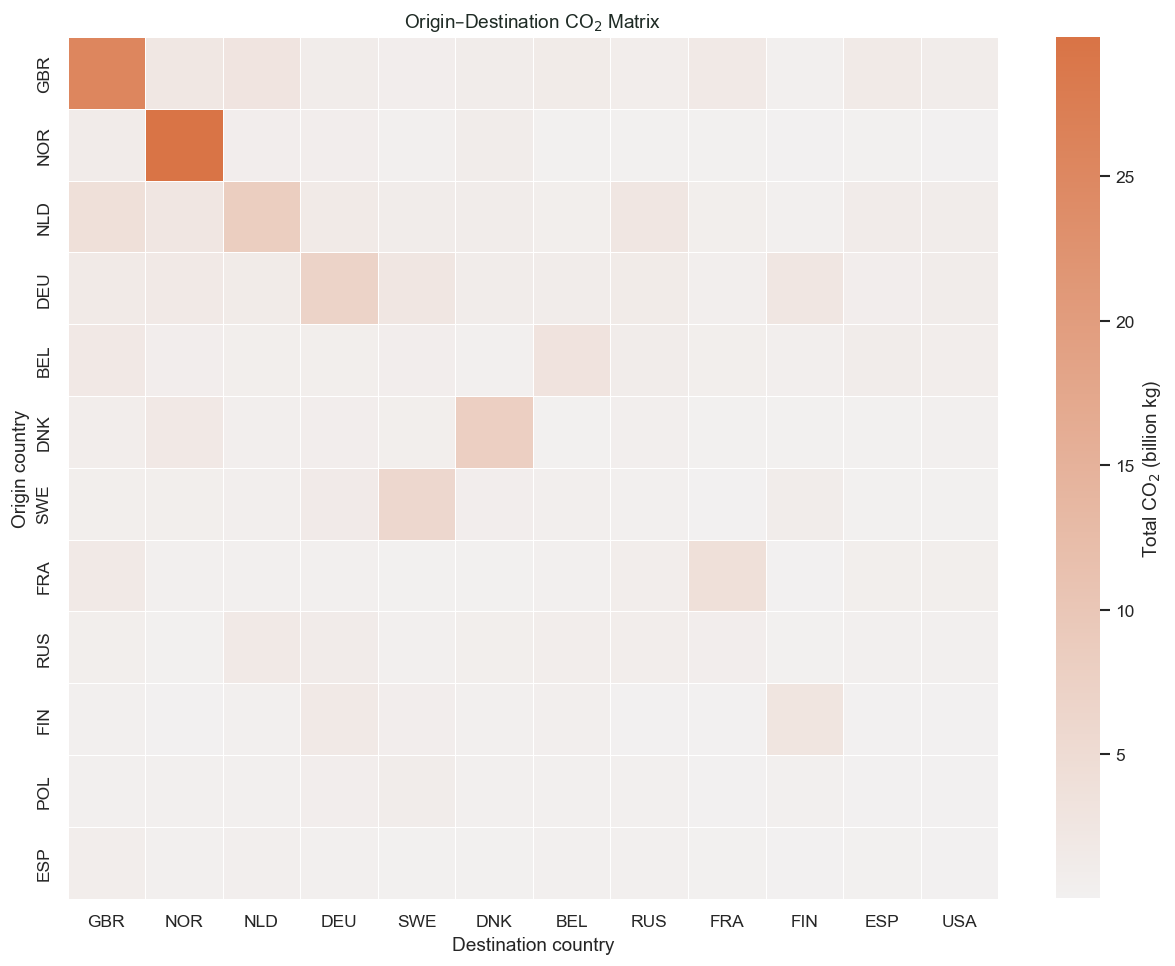

Saved: /Users/vivi/Documents/ERP/eda_outputs/figures/origin_destination_co2_heatmap.png


In [6]:
top_origins = df.groupby("country_o")["CO2"].sum().nlargest(12).index
top_destinations = df.groupby("country_d")["CO2"].sum().nlargest(12).index
heatmap_source = df[df["country_o"].isin(top_origins) & df["country_d"].isin(top_destinations)]
od_matrix = heatmap_source.pivot_table(index="country_o", columns="country_d", values="CO2", aggfunc="sum", fill_value=0)
od_matrix = od_matrix.reindex(index=top_origins, columns=top_destinations, fill_value=0)
save_table(od_matrix.reset_index(), "origin_destination_co2_matrix.csv")

fig, ax = plt.subplots(figsize=(10.5, 8.2))
sns.heatmap(
    od_matrix / 1e9,
    cmap=sns.light_palette(ORANGE, as_cmap=True),
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": r"Total CO$_2$ (billion kg)"},
    ax=ax,
)
ax.set_title(r"Origin–Destination CO$_2$ Matrix")
ax.set_xlabel("Destination country")
ax.set_ylabel("Origin country")
fig.tight_layout()
save_figure(fig, "origin_destination_co2_heatmap.png")


## 6. Reproducible analytical summaries

Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/country_pair_summary.csv
Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/monthly_co2_trend.csv
Saved: /Users/vivi/Documents/ERP/eda_outputs/tables/country_pair_co2_intensity.csv


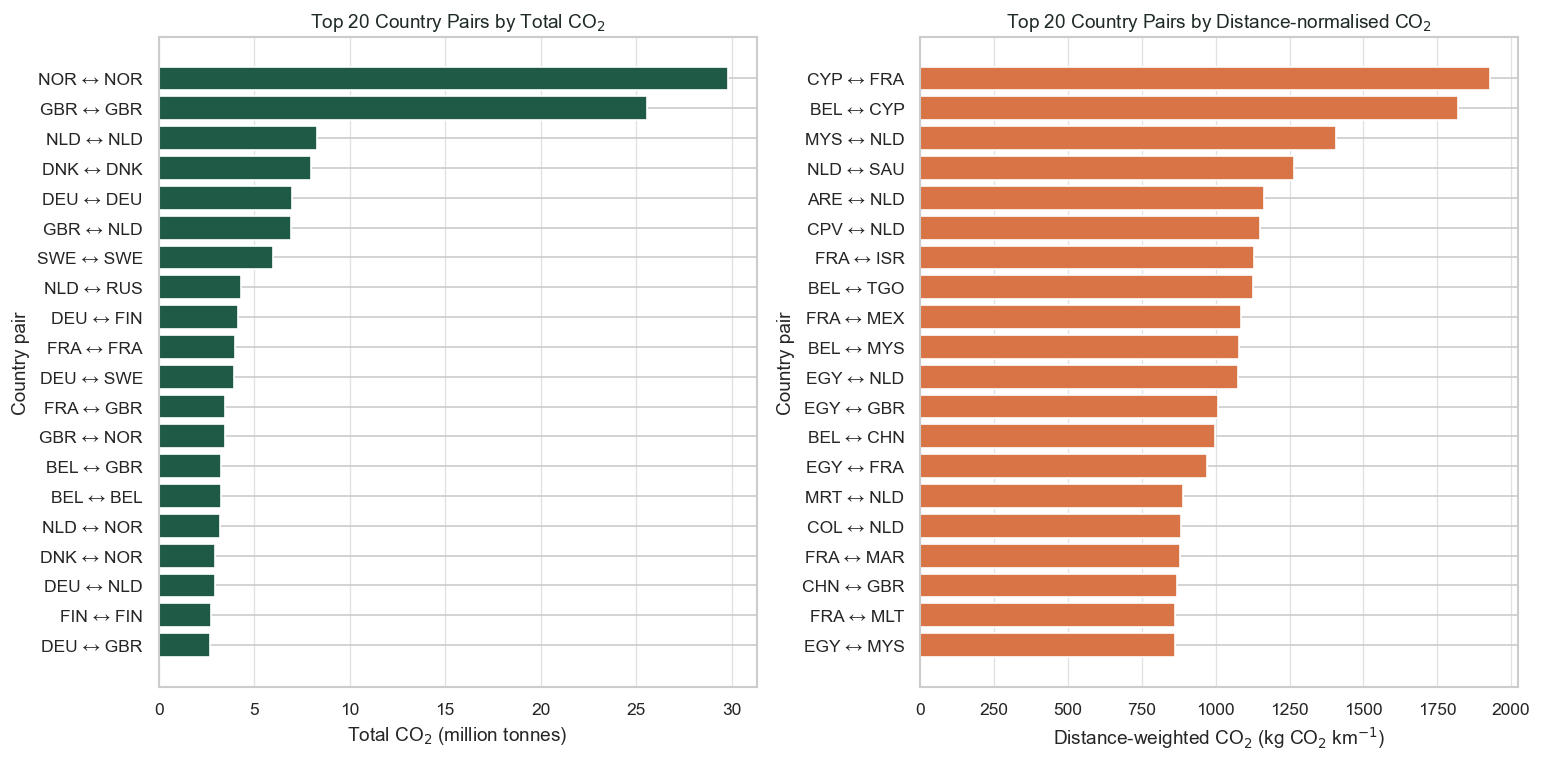

Saved: /Users/vivi/Documents/ERP/eda_outputs/figures/country_pair_total_and_intensity.png
EDA complete. Outputs saved to: /Users/vivi/Documents/ERP/eda_outputs


In [7]:
country_pair_summary = (
    df.groupby("country_pair", dropna=False)
    .agg(record_count=("CO2", "size"), unique_vessels=("imo", "nunique"), total_co2_kg=("CO2", "sum"), total_distance_km=("delta_dist_km", "sum"))
    .reset_index().sort_values("total_co2_kg", ascending=False)
)
save_table(country_pair_summary, "country_pair_summary.csv")

monthly_summary = (
    df.groupby("departure_month")
    .agg(record_count=("CO2", "size"), total_co2_kg=("CO2", "sum"), total_distance_km=("delta_dist_km", "sum"))
    .reset_index().sort_values("departure_month")
)
save_table(monthly_summary, "monthly_co2_trend.csv")

valid = df["delta_dist_km"] > 0
country_pair_intensity = (
    df.loc[valid].groupby("country_pair", dropna=False)
    .agg(record_count=("CO2", "size"), total_co2_kg=("CO2", "sum"), total_distance_km=("delta_dist_km", "sum"))
    .reset_index()
)
country_pair_intensity["co2_per_km"] = country_pair_intensity["total_co2_kg"] / country_pair_intensity["total_distance_km"]
country_pair_intensity = country_pair_intensity.loc[
    country_pair_intensity["record_count"] >= MIN_COUNTRY_PAIR_INTENSITY_RECORDS
].sort_values("co2_per_km", ascending=False)
save_table(country_pair_intensity, "country_pair_co2_intensity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
top_total = country_pair_summary.head(TOP_N).sort_values("total_co2_kg")
axes[0].barh(top_total["country_pair"], top_total["total_co2_kg"] / 1e9, color=GREEN)
axes[0].set_title(f"Top {TOP_N} Country Pairs by Total " + r"CO$_2$")
axes[0].set_xlabel(r"Total CO$_2$ (million tonnes)")
axes[0].set_ylabel("Country pair")
axes[0].grid(axis="x", color="#DDE3DF", linewidth=0.8)

top_intensity = country_pair_intensity.head(TOP_N).sort_values("co2_per_km")
axes[1].barh(top_intensity["country_pair"], top_intensity["co2_per_km"], color=ORANGE)
axes[1].set_title(f"Top {TOP_N} Country Pairs by Distance-normalised " + r"CO$_2$")
axes[1].set_xlabel(r"Distance-weighted CO$_2$ (kg CO$_2$ km$^{-1}$)")
axes[1].set_ylabel("Country pair")
axes[1].grid(axis="x", color="#DDE3DF", linewidth=0.8)
fig.tight_layout()
save_figure(fig, "country_pair_total_and_intensity.png")

print(f"EDA complete. Outputs saved to: {OUTPUT_DIR}")
